In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("bank-marketing.csv")

# Display the first 5 rows
df.head()

,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"56;""housemaid"";""married"";""basic.4y"";""no"";""no"";..."
1,"57;""services"";""married"";""high.school"";""unknown..."
2,"37;""services"";""married"";""high.school"";""no"";""ye..."
3,"40;""admin."";""married"";""basic.6y"";""no"";""no"";""no..."
4,"56;""services"";""married"";""high.school"";""no"";""no..."


In [2]:
df.shape

(41188, 1)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                        Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                        --------------  ----- 
 0   age;"job";"marital";"education";"default";"housing";"loan";"contact";"month";"day_of_week";"duration";"campaign";"pdays";"previous";"poutcome";"emp.var.rate";"cons.price.idx";"cons.conf.idx";"euribor3m";"nr.employed";"y"  41188 non-null  object
dtypes: object(1)
memory usage: 321.9+ KB


In [4]:
df.columns

Index(['age;"job";"marital";"education";"default";"housing";"loan";"contact";"month";"day_of_week";"duration";"campaign";"pdays";"previous";"poutcome";"emp.var.rate";"cons.price.idx";"cons.conf.idx";"euribor3m";"nr.employed";"y"'], dtype='object')

In [5]:
df.dtypes

age;"job";"marital";"education";"default";"housing";"loan";"contact";"month";"day_of_week";"duration";"campaign";"pdays";"previous";"poutcome";"emp.var.rate";"cons.price.idx";"cons.conf.idx";"euribor3m";"nr.employed";"y"    object
dtype: object

In [6]:
df.columns

Index(['age;"job";"marital";"education";"default";"housing";"loan";"contact";"month";"day_of_week";"duration";"campaign";"pdays";"previous";"poutcome";"emp.var.rate";"cons.price.idx";"cons.conf.idx";"euribor3m";"nr.employed";"y"'], dtype='object')

In [7]:
print(df.shape)
print(df.head())

(41188, 1)
  age;"job";"marital";"education";"default";"housing";"loan";"contact";"month";"day_of_week";"duration";"campaign";"pdays";"previous";"poutcome";"emp.var.rate";"cons.price.idx";"cons.conf.idx";"euribor3m";"nr.employed";"y"
0  56;"housemaid";"married";"basic.4y";"no";"no";...                                                                                                                                                                          
1  57;"services";"married";"high.school";"unknown...                                                                                                                                                                          
2  37;"services";"married";"high.school";"no";"ye...                                                                                                                                                                          
3  40;"admin.";"married";"basic.6y";"no";"no";"no...                                             

In [8]:
df.columns = df.columns.str.strip()

In [9]:
df = pd.read_csv("bank-marketing.csv", sep=";")
df.columns = df.columns.str.strip()

df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [10]:
df["y"].value_counts(normalize=True) * 100

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

In [11]:
subscription_rate = df["y"].value_counts(normalize=True) * 100

print(f"Did not subscribe: {subscription_rate['no']:.2f}%")
print(f"Subscribed: {subscription_rate['yes']:.2f}%")

Did not subscribe: 88.73%
Subscribed: 11.27%


In [12]:
df["job"].value_counts()

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

In [13]:
job_subscription = pd.crosstab(
    df["job"],
    df["y"],
    normalize="index"
) * 100

job_subscription

y,no,yes
job,,
admin.,87.027442,12.972558
blue-collar,93.105684,6.894316
entrepreneur,91.483516,8.516484
housemaid,90.000000,10.000000
management,88.782490,11.217510
retired,74.767442,25.232558
self-employed,89.514426,10.485574
services,91.861930,8.138070
student,68.571429,31.428571


In [14]:
job_subscription.sort_values("yes", ascending=False)

y,no,yes
job,,
student,68.571429,31.428571
retired,74.767442,25.232558
unemployed,85.798817,14.201183
admin.,87.027442,12.972558
management,88.782490,11.217510
unknown,88.787879,11.212121
technician,89.173958,10.826042
self-employed,89.514426,10.485574
housemaid,90.000000,10.000000


In [15]:
monthly_subscriptions = df[df["y"] == "yes"]["month"].value_counts()

monthly_subscriptions

month
may    886
aug    655
jul    649
jun    559
apr    539
nov    416
oct    315
mar    276
sep    256
dec     89
Name: count, dtype: int64

In [16]:
month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]

monthly_subscriptions = monthly_subscriptions.reindex(month_order)

monthly_subscriptions

month
jan      NaN
feb      NaN
mar    276.0
apr    539.0
may    886.0
jun    559.0
jul    649.0
aug    655.0
sep    256.0
oct    315.0
nov    416.0
dec     89.0
Name: count, dtype: float64

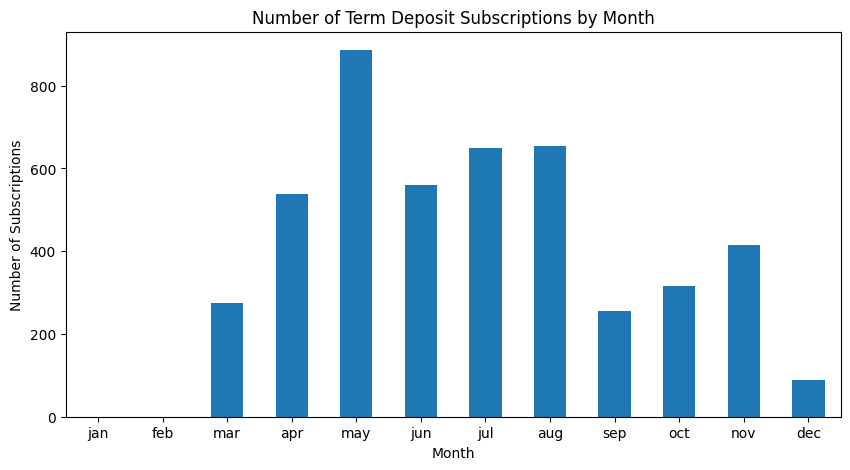

In [17]:
plt.figure(figsize=(10, 5))

monthly_subscriptions.plot(kind="bar")

plt.title("Number of Term Deposit Subscriptions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Subscriptions")
plt.xticks(rotation=0)

plt.show()

In [18]:
df["previous"].describe()

count    41188.000000
mean         0.172963
std          0.494901
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: previous, dtype: float64

In [19]:
df["previous"].value_counts().sort_index()

previous
0    35563
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: count, dtype: int64

In [20]:
previous_subscription = pd.crosstab(
    df["previous"],
    df["y"],
    normalize="index"
) * 100

previous_subscription

y,no,yes
previous,,
0,91.167787,8.832213
1,78.798509,21.201491
2,53.580902,46.419098
3,40.740741,59.259259
4,45.714286,54.285714
5,27.777778,72.222222
6,40.000000,60.000000
7,100.000000,0.000000


In [21]:
previous_subscription.sort_values("yes", ascending=False)

y,no,yes
previous,,
5,27.777778,72.222222
6,40.000000,60.000000
3,40.740741,59.259259
4,45.714286,54.285714
2,53.580902,46.419098
1,78.798509,21.201491
0,91.167787,8.832213
7,100.000000,0.000000


In [22]:
df.groupby("previous")["y"].value_counts()

previous  y  
0         no     32422
          yes     3141
1         no      3594
          yes      967
2         no       404
          yes      350
3         yes      128
          no        88
4         yes       38
          no        32
5         yes       13
          no         5
6         yes        3
          no         2
7         no         1
Name: count, dtype: int64

In [23]:
campaign_subscription = pd.crosstab(
    df["campaign"],
    df["y"],
    normalize="index"
) * 100

campaign_subscription.sort_values("yes", ascending=False)

y,no,yes
campaign,,
1,86.962929,13.037071
2,88.543046,11.456954
3,89.252949,10.747051
4,90.607318,9.392682
6,92.339122,7.660878
5,92.495310,7.504690
17,93.103448,6.896552
11,93.220339,6.779661
23,93.750000,6.250000


In [24]:
df.groupby("campaign")["y"].value_counts()

campaign  y  
1         no     15342
          yes     2300
2         no      9359
          yes     1211
3         no      4767
          yes      574
4         no      2402
          yes      249
5         no      1479
          yes      120
6         no       904
          yes       75
7         no       591
          yes       38
8         no       383
          yes       17
9         no       266
          yes       17
10        no       213
          yes       12
11        no       165
          yes       12
12        no       122
          yes        3
13        no        88
          yes        4
14        no        68
          yes        1
15        no        49
          yes        2
16        no        51
17        no        54
          yes        4
18        no        33
19        no        26
20        no        30
21        no        24
22        no        17
23        no        15
          yes        1
24        no        15
25        no         8
26        no        

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [26]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [27]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [28]:
for column in df.select_dtypes(include="object").columns:
    print("\n", column)
    print(df[column].value_counts().head(10))


 job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
Name: count, dtype: int64

 marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

 education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

 default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

 housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

 loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

 contact
contact
cellular     26144
telephone    15044
Nam

In [29]:
unknown_counts = {}

for column in df.select_dtypes(include="object").columns:
    unknown_counts[column] = (df[column] == "unknown").sum()

unknown_counts = pd.Series(unknown_counts)

unknown_counts.sort_values(ascending=False)

default        8597
education      1731
housing         990
loan            990
job             330
marital          80
contact           0
month             0
day_of_week       0
poutcome          0
y                 0
dtype: int64

In [30]:
unknown_percent = (unknown_counts / len(df)) * 100

unknown_summary = pd.DataFrame({
    "Unknown Count": unknown_counts,
    "Percentage": unknown_percent
})

unknown_summary.sort_values("Unknown Count", ascending=False)

,Unknown Count,Percentage
default,8597,20.872584
education,1731,4.202680
housing,990,2.403613
loan,990,2.403613
job,330,0.801204
marital,80,0.194231
contact,0,0.000000
month,0,0.000000
day_of_week,0,0.000000
poutcome,0,0.000000


In [31]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [32]:
df.select_dtypes(include=["int64", "float64"]).columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [33]:
for column in df.select_dtypes(include=["int64", "float64"]).columns:
    print("\n", column)
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())
    print("Mean:", df[column].mean())
    print("Median:", df[column].median())


 age
Minimum: 17
Maximum: 98
Mean: 40.02406040594348
Median: 38.0

 duration
Minimum: 0
Maximum: 4918
Mean: 258.2850101971448
Median: 180.0

 campaign
Minimum: 1
Maximum: 56
Mean: 2.567592502670681
Median: 2.0

 pdays
Minimum: 0
Maximum: 999
Mean: 962.4754540157328
Median: 999.0

 previous
Minimum: 0
Maximum: 7
Mean: 0.17296299893172767
Median: 0.0

 emp.var.rate
Minimum: -3.4
Maximum: 1.4
Mean: 0.08188550063125165
Median: 1.1

 cons.price.idx
Minimum: 92.201
Maximum: 94.767
Mean: 93.57566436826262
Median: 93.749

 cons.conf.idx
Minimum: -50.8
Maximum: -26.9
Mean: -40.50260027192386
Median: -41.8

 euribor3m
Minimum: 0.634
Maximum: 5.045
Mean: 3.621290812858114
Median: 4.857

 nr.employed
Minimum: 4963.6
Maximum: 5228.1
Mean: 5167.035910944936
Median: 5191.0


In [34]:
numeric_summary = df.select_dtypes(include=["int64", "float64"]).describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [35]:
df["previously_contacted"] = (df["pdays"] != 999).astype(int)

In [36]:
df["previously_contacted"].value_counts()

previously_contacted
0    39673
1     1515
Name: count, dtype: int64

In [37]:
df["previously_contacted"].value_counts(normalize=True) * 100

previously_contacted
0    96.321744
1     3.678256
Name: proportion, dtype: float64

In [38]:
y = df["y"]

In [39]:
X = df.drop(columns=["y", "duration", "pdays"])

In [40]:
X.shape

(41188, 19)

In [41]:
X.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'previously_contacted'],
      dtype='object')

In [42]:
y = y.map({"no": 0, "yes": 1})

In [43]:
y.value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [45]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (32950, 19)
Testing set: (8238, 19)


In [46]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
y
0    88.734446
1    11.265554
Name: proportion, dtype: float64

Testing target distribution:
y
0    88.73513
1    11.26487
Name: proportion, dtype: float64


In [47]:
categorical_features = X_train.select_dtypes(include=["object"]).columns
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns

print("Categorical features:")
print(list(categorical_features))

print("\nNumerical features:")
print(list(numerical_features))

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numerical features:
['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted']


In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, f1_score

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), list(categorical_features)),
    ("num", StandardScaler(), list(numerical_features)),
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                            class_weight="balanced", n_jobs=-1, random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05,
                                                        max_iter=300, random_state=42),
}

fitted, scores = {}, []
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)]).fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    fitted[name] = (pipe, proba)
    scores.append({"Model": name,
                   "ROC AUC": roc_auc_score(y_test, proba),
                   "PR AUC": average_precision_score(y_test, proba)})
pd.DataFrame(scores).round(3)

,Model,ROC AUC,PR AUC
0,Logistic Regression,0.801,0.460
1,Random Forest,0.808,0.491
2,Gradient Boosting,0.812,0.486


In [49]:
proba = fitted["Gradient Boosting"][1]
order = np.argsort(-proba)
y_sorted = y_test.values[order]
rows = []
for frac in [0.1, 0.2, 0.3, 0.5, 1.0]:
    k = int(len(y_sorted) * frac)
    rows.append({"Customers called (top %)": int(frac*100),
                 "Subscribers captured (%)": round(y_sorted[:k].sum()/y_sorted.sum()*100, 1),
                 "Success rate (%)": round(y_sorted[:k].mean()*100, 1)})
pd.DataFrame(rows)

,Customers called (top %),Subscribers captured (%),Success rate (%)
0,10,47.5,53.6
1,20,66.6,37.5
2,30,74.4,27.9
3,50,84.1,18.9
4,100,100.0,11.3


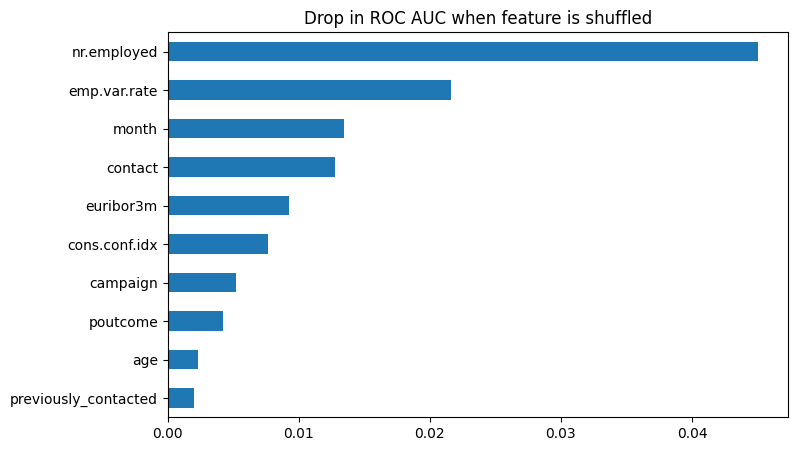

In [50]:
from sklearn.inspection import permutation_importance
pipe = fitted["Gradient Boosting"][0]
pi = permutation_importance(pipe, X_test, y_test, scoring="roc_auc",
                            n_repeats=5, random_state=42, n_jobs=-1)
imp = pd.Series(pi.importances_mean, X_test.columns).sort_values()
imp.tail(10).plot(kind="barh", figsize=(8, 5), title="Drop in ROC AUC when feature is shuffled")
plt.show()

In [51]:
lr = fitted["Logistic Regression"][0]
coefs = pd.Series(lr.named_steps["model"].coef_[0],
                  lr.named_steps["prep"].get_feature_names_out()).sort_values()
pd.concat([coefs.head(8), coefs.tail(8)])

num__emp.var.rate           -2.248504
cat__month_jun              -0.806959
cat__month_may              -0.653424
cat__month_nov              -0.577950
cat__contact_telephone      -0.330238
cat__poutcome_failure       -0.310134
cat__month_apr              -0.233418
cat__marital_divorced       -0.169394
cat__education_illiterate    0.307258
cat__job_retired             0.360137
num__euribor3m               0.372503
num__nr.employed             0.419592
cat__month_dec               0.435883
cat__month_aug               0.458479
num__cons.price.idx          1.121214
cat__month_mar               1.272878
dtype: float64